# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Srinadh2314/srinadh-flyrank-intership/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.


## Distributions

The key signals for this lane are search visibility, search clicks, average position, engagement, and content freshness where available. I will inspect their distributions before using thresholds because search metrics can be highly skewed, with many low-volume pages and a smaller number of high-volume pages.
The distribution is highly right-skewed: most rows have very low average GSC impressions, while a small number of rows have much larger values. This heavy tail means simple thresholds should be interpreted carefully.

In [11]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    con
except NameError:
    from google.colab import userdata
    import duckdb

    HF_TOKEN = userdata.get("HF_TOKEN")

    con = duckdb.connect()

    con.execute(f"""
    CREATE OR REPLACE SECRET hf (
        TYPE HUGGINGFACE,
        TOKEN '{HF_TOKEN}'
    )
    """)

    print("Warehouse connection ready")


signal_query = """
SELECT
    client_hash_id,
    content_hash_id,
    AVG(gsc_impressions) AS avg_gsc_impressions,
    AVG(gsc_clicks) AS avg_gsc_clicks,
    AVG(gsc_avg_position) AS avg_gsc_avg_position,
    AVG(ga4_sessions) AS avg_ga4_sessions,
    AVG(scroll_events) AS avg_scroll_events
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-02/*.parquet'
)
GROUP BY client_hash_id, content_hash_id
"""

signal_df = con.execute(signal_query).df()

print("Rows:", len(signal_df))

summary = signal_df[
    [
        "avg_gsc_impressions",
        "avg_gsc_clicks",
        "avg_gsc_avg_position",
        "avg_ga4_sessions",
        "avg_scroll_events"
    ]
].describe().T

display(summary)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 321546


,count,mean,std,min,25%,50%,75%,max
avg_gsc_impressions,321546.0,21.955622,107.389437,0.0,0.000000,0.000000,4.428571,7264.321429
avg_gsc_clicks,321546.0,0.073515,0.591543,0.0,0.000000,0.000000,0.000000,118.214286
avg_gsc_avg_position,153559.0,12.702216,13.977253,0.0,4.731159,7.935419,14.806570,633.000000
avg_ga4_sessions,171869.0,0.073647,0.601277,0.0,0.000000,0.000000,0.000000,144.214286
avg_scroll_events,171869.0,0.008915,0.267463,0.0,0.000000,0.000000,0.000000,108.464286


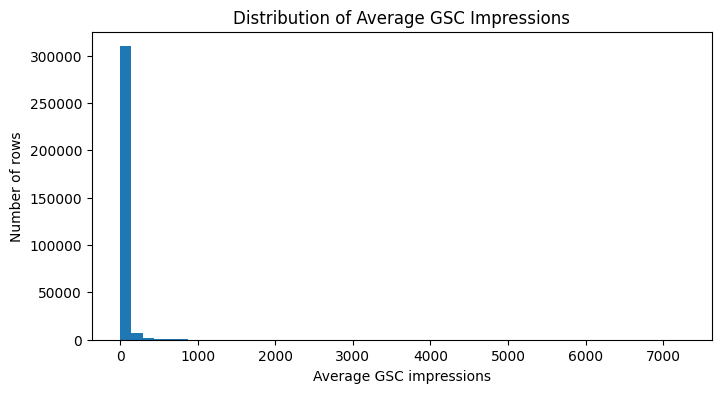

In [12]:
plt.figure(figsize=(8, 4))

plt.hist(
    signal_df["avg_gsc_impressions"].fillna(0),
    bins=50
)

plt.xlabel("Average GSC impressions")
plt.ylabel("Number of rows")
plt.title("Distribution of Average GSC Impressions")

plt.show()

## Signal test verdicts

**Signal 1 — avg_gsc_impressions: CONFIRMED**

The target rate is highest when average GSC impressions are zero (0.828) and falls sharply as impressions increase. This supports the directional assumption that very low search visibility is strongly associated with the selected outcome proxy.

**Signal 2 — avg_gsc_avg_position: MIXED**

The target rate is relatively similar across the 0–5, 5–10, 10–20, and 20–50 position buckets, with a higher rate again at 50+. The relationship is therefore not cleanly monotonic and should not be reduced to a simple threshold without further validation.

**Signal 3 — avg_gsc_clicks: CONFIRMED**

The target rate is much higher for rows with zero average GSC clicks (0.567) and decreases sharply as click volume increases. This supports using click activity as a directional visibility signal, while avoiding causal interpretation.

In [13]:
# Load the March outcome proxy

label_query = """
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS march_impressions
FROM read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
GROUP BY client_hash_id, content_hash_id
"""

label_df = con.execute(label_query).df()


audit_df = signal_df.merge(
    label_df,
    on=["client_hash_id", "content_hash_id"],
    how="inner"
)

audit_df["target"] = (
    audit_df["march_impressions"] == 0
).astype(int)

print("Audit rows:", len(audit_df))
print("Target rate:", round(audit_df["target"].mean(), 3))


audit_df["impression_bucket"] = pd.cut(
    audit_df["avg_gsc_impressions"],
    bins=[-0.01, 0, 10, 100, 500, np.inf],
    labels=["0", "1-10", "11-100", "101-500", "500+"]
)

signal1 = (
    audit_df
    .groupby("impression_bucket", observed=False)
    .agg(
        n=("target", "size"),
        mean_target=("target", "mean")
    )
    .reset_index()
)

print("\nSignal 1 — avg_gsc_impressions")
display(signal1)


audit_df["position_bucket"] = pd.cut(
    audit_df["avg_gsc_avg_position"],
    bins=[-0.01, 5, 10, 20, 50, np.inf],
    labels=["0-5", "5-10", "10-20", "20-50", "50+"]
)

signal2 = (
    audit_df
    .groupby("position_bucket", observed=False)
    .agg(
        n=("target", "size"),
        mean_target=("target", "mean")
    )
    .reset_index()
)

print("\nSignal 2 — avg_gsc_avg_position")
display(signal2)



audit_df["click_bucket"] = pd.cut(
    audit_df["avg_gsc_clicks"],
    bins=[-0.01, 0, 0.1, 1, 5, np.inf],
    labels=["0", "0.01-0.1", "0.11-1", "1.01-5", "5+"]
)

signal3 = (
    audit_df
    .groupby("click_bucket", observed=False)
    .agg(
        n=("target", "size"),
        mean_target=("target", "mean")
    )
    .reset_index()
)

print("\nSignal 3 — avg_gsc_clicks")
display(signal3)

Audit rows: 303572
Target rate: 0.468

Signal 1 — avg_gsc_impressions


,impression_bucket,n,mean_target
0,0,158293,0.827529
1,1-10,84326,0.130411
2,11-100,44231,0.000995
3,101-500,14527,0.000000
4,500+,2195,0.000000



Signal 2 — avg_gsc_avg_position


,position_bucket,n,mean_target
0,0-5,41301,0.086124
1,5-10,50867,0.078577
2,10-20,29514,0.064580
3,20-50,19162,0.057301
4,50+,4435,0.108906



Signal 3 — avg_gsc_clicks


,click_bucket,n,mean_target
0,0,249834,0.567021
1,0.01-0.1,22837,0.014625
2,0.11-1,25949,0.001426
3,1.01-5,4465,0.000224
4,5+,487,0.000000


## 3. The flag-linked test

**Flag-linked signal: search visibility / volume**

Search volume is one of the signals used behind the quick-win flag. I test whether average GSC impressions show a meaningful relationship with the selected outcome proxy in this data.

The result is descriptive and directional. It supports or weakens the signal assumption, but it does not prove that the flag or any content action causes an outcome.

In [14]:


audit_df["volume_group"] = np.where(
    audit_df["avg_gsc_impressions"] == 0,
    "Zero impressions",
    "Has impressions"
)

flag_linked_test = (
    audit_df
    .groupby("volume_group")
    .agg(
        n=("target", "size"),
        mean_target=("target", "mean")
    )
    .reset_index()
)

display(flag_linked_test)

zero_rate = flag_linked_test.loc[
    flag_linked_test["volume_group"] == "Zero impressions",
    "mean_target"
].iloc[0]

nonzero_rate = flag_linked_test.loc[
    flag_linked_test["volume_group"] == "Has impressions",
    "mean_target"
].iloc[0]

if zero_rate > nonzero_rate:
    verdict = "CONFIRMED"
elif zero_rate < nonzero_rate:
    verdict = "OPPOSITE"
else:
    verdict = "MIXED"

print("Flag-linked signal verdict:", verdict)


,volume_group,n,mean_target
0,Has impressions,145279,0.075999
1,Zero impressions,158293,0.827529


Flag-linked signal verdict: CONFIRMED



## 4. What this means in practice

The audit shows that very low search visibility is strongly associated with the selected outcome proxy, while average position has a weaker and less consistent relationship. For a content team, visibility and click signals can therefore help prioritize review, but they should be treated as decision-support signals rather than automatic action rules.

In [15]:

print("Signal 1 — avg_gsc_impressions: CONFIRMED")
print("Signal 2 — avg_gsc_avg_position: MIXED")
print("Signal 3 — avg_gsc_clicks: CONFIRMED")
print("Flag-linked signal — impressions/volume: CONFIRMED")


Signal 1 — avg_gsc_impressions: CONFIRMED
Signal 2 — avg_gsc_avg_position: MIXED
Signal 3 — avg_gsc_clicks: CONFIRMED
Flag-linked signal — impressions/volume: CONFIRMED


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.